#  Anomaly Root Cause Taxonomy

**Goal**: Combine everything we've learned from Notebooks 02-04 into a structured **failure mode taxonomy** — a catalog of "what goes wrong and how to recognize it."

**Why this matters**: The CoT agent doesn't just need to detect anomalies — it needs to EXPLAIN them. To do that, it needs a knowledge base of:
1. What failure modes exist (categories)
2. What events characterize each mode (signatures)
3. What the root cause is (explanation)
4. What remediation to apply (action)




In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast
import json
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

DATA_DIR = "../../preprocessed"

# Load all datasets
matrix_df = pd.read_csv(os.path.join(DATA_DIR, "Event_occurrence_matrix.csv"))
traces_df = pd.read_csv(os.path.join(DATA_DIR, "Event_traces.csv"))
templates_df = pd.read_csv(os.path.join(DATA_DIR, "HDFS.log_templates.csv"))

# Parse sequences
def parse_features(x):
    if pd.isna(x):
        return []
    return x.strip("[]").split(",")

traces_df["sequence"] = traces_df["Features"].apply(parse_features)
traces_df["seq_length"] = traces_df["sequence"].apply(len)

# Load prior findings (from NB03)
with open('../data/sequence_analysis_findings.json', 'r') as f:
    seq_findings = json.load(f)

# Split
anomaly_traces = traces_df[traces_df['Label'] == 'Fail']
normal_traces = traces_df[traces_df['Label'] == 'Success']

event_cols = [col for col in matrix_df.columns if col.startswith('E')]

print(f"✅ Loaded all data")
print(f"   Anomaly traces: {len(anomaly_traces):,}")
print(f"   Normal traces:  {len(normal_traces):,}")
print(f"   Event types:    {len(event_cols)}")


✅ Loaded all data
   Anomaly traces: 16,838
   Normal traces:  558,223
   Event types:    29


In [31]:
matrix_df.head(10)  # Show the first 10 rows of the matrix DataFrame

,BlockId,Label,Type,E1,E2,E3,E4,E5,E6,E7,...,E20,E21,E22,E23,E24,E25,E26,E27,E28,E29
0,blk_-1608999687919862906,Success,NaN,0,0,203,0,10,7,0,...,0,10,1,10,0,4,10,0,0,0
1,blk_7503483334202473044,Success,NaN,0,2,1,0,3,0,0,...,0,3,1,3,0,0,3,0,0,0
2,blk_-3544583377289625738,Fail,21.0,0,0,203,0,3,0,0,...,1,3,1,3,0,0,3,0,0,0
3,blk_-9073992586687739851,Success,NaN,0,3,0,0,3,0,0,...,0,3,1,3,0,0,3,0,0,0
4,blk_7854771516489510256,Success,NaN,0,3,1,15,3,0,0,...,0,3,1,3,0,0,3,0,0,0
5,blk_1717858812220360316,Success,NaN,0,3,1,15,3,0,0,...,0,3,1,3,0,0,3,0,0,0
6,blk_-2519617320378473615,Success,NaN,0,3,1,15,3,0,0,...,0,3,1,3,0,0,3,0,0,0
7,blk_7063315473424667801,Success,NaN,0,3,1,15,3,0,0,...,0,3,1,3,0,0,3,0,0,0
8,blk_8586544123689943463,Success,NaN,0,3,1,15,3,0,0,...,0,3,1,3,0,0,3,0,0,0
9,blk_2765344736980045501,Success,NaN,0,3,1,15,3,0,0,...,0,3,1,3,0,0,3,0,0,0


In [32]:
traces_df.head(10)  # Show the first 10 rows of the traces DataFrame


,BlockId,Label,Type,Features,TimeInterval,Latency,sequence,seq_length
0,blk_-1608999687919862906,Success,NaN,"[E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802,"[E5, E22, E5, E5, E11, E11, E9, E9, E11, E9, E...",269
1,blk_7503483334202473044,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802,"[E5, E5, E22, E5, E11, E9, E11, E9, E11, E9, E...",22
2,blk_-3544583377289625738,Fail,21.0,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E3,E26,E26,...","[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",3797,"[E5, E22, E5, E5, E11, E9, E11, E9, E11, E9, E...",223
3,blk_-9073992586687739851,Success,NaN,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",50448,"[E5, E22, E5, E5, E11, E9, E11, E9, E11, E9, E...",22
4,blk_7854771516489510256,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 48.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50583,"[E5, E5, E22, E5, E11, E9, E11, E9, E11, E9, E...",38
5,blk_1717858812220360316,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 11.0, 43.0, 0.0, 0.0, 0.0, 0.0, 0.0...",50458,"[E5, E5, E22, E5, E11, E9, E11, E9, E11, E9, E...",38
6,blk_-2519617320378473615,Success,NaN,"[E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 9.0, 43.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50523,"[E5, E22, E5, E5, E11, E11, E9, E9, E11, E9, E...",38
7,blk_7063315473424667801,Success,NaN,"[E5,E5,E5,E22,E11,E9,E11,E9,E26,E26,E11,E9,E26...","[1.0, 0.0, 0.0, 58.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50818,"[E5, E5, E5, E22, E11, E9, E11, E9, E26, E26, ...",38
8,blk_8586544123689943463,Success,NaN,"[E5,E5,E5,E22,E11,E9,E11,E11,E9,E9,E26,E26,E26...","[1.0, 0.0, 0.0, 36.0, 0.0, 1.0, 0.0, 0.0, 0.0,...",50795,"[E5, E5, E5, E22, E11, E9, E11, E11, E9, E9, E...",38
9,blk_2765344736980045501,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E26,E11,E9,E26,E26...","[0.0, 0.0, 1.0, 28.0, 0.0, 0.0, 0.0, 0.0, 1.0,...",50528,"[E5, E5, E22, E5, E11, E9, E11, E9, E26, E11, ...",38


## Step 1: What Types of Anomalies Exist?

The `Event_traces.csv` has a `Type` column that's only populated for anomaly traces (it's NaN for normal ones). This column tells us the **anomaly sub-type** — a numeric code that groups similar failures together.

Let's see how many types there are and how they're distributed.


Number of distinct anomaly types: 26

Anomaly Type Distribution:
  Type    Count   Percentage
──────────────────────────────
     0    2,809       16.68%
     1      953        5.66%
     3    2,950       17.52%
     4    1,240        7.36%
     5    4,167       24.75%
     7      476        2.83%
     8       45        0.27%
     9       34        0.20%
    10        3        0.02%
    11        3        0.02%
    12      130        0.77%
    13       10        0.06%
    16       22        0.13%
    17        3        0.02%
    18        9        0.05%
    19        8        0.05%
    20        7        0.04%
    21      724        4.30%
    22        9        0.05%
    23        1        0.01%
    24        3        0.02%
    25        2        0.01%
    27        3        0.02%
    28        1        0.01%
    30        1        0.01%
    31    3,225       19.15%


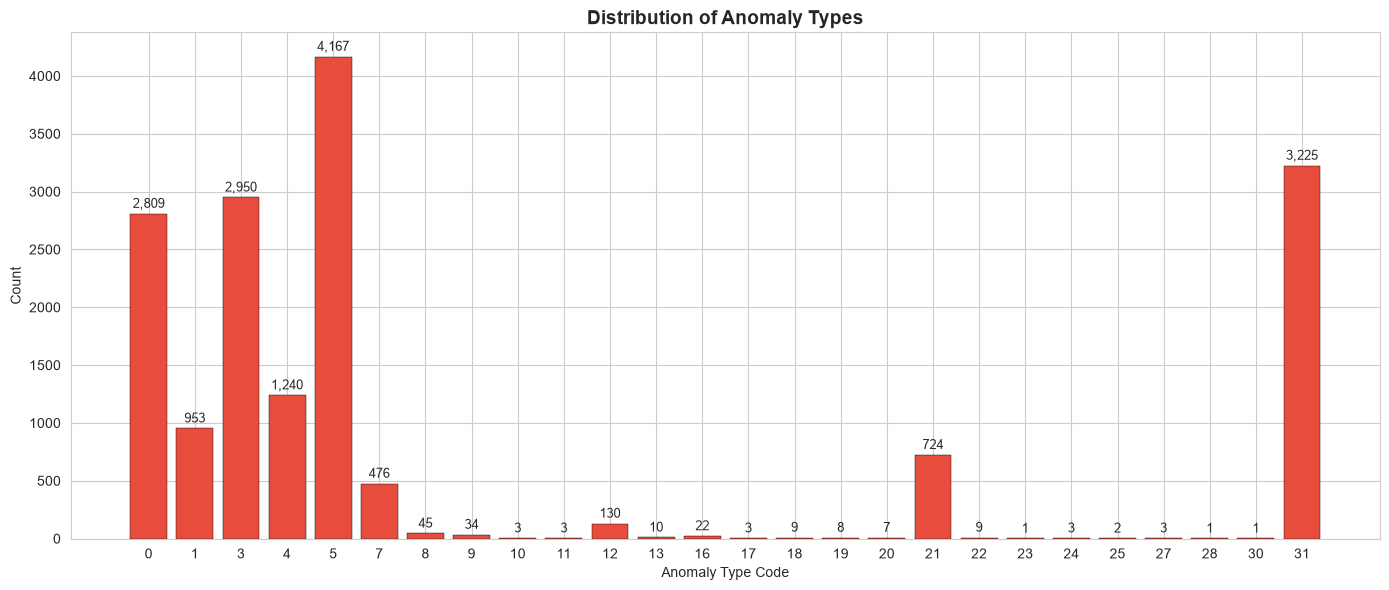

In [33]:
# Anomaly type distribution
anomaly_types = anomaly_traces['Type'].value_counts().sort_index()

print(f"Number of distinct anomaly types: {len(anomaly_types)}")
print(f"\nAnomaly Type Distribution:")
print(f"{'Type':>6} {'Count':>8} {'Percentage':>12}")
print(f"{'─'*30}")
for atype, count in anomaly_types.items():
    pct = count / len(anomaly_traces) * 100
    print(f"{int(atype):>6} {count:>8,} {pct:>11.2f}%")

# Visualize
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar([str(int(t)) for t in anomaly_types.index], anomaly_types.values, 
       color='#e74c3c', edgecolor='black', linewidth=0.3)
ax.set_title('Distribution of Anomaly Types', fontsize=14, fontweight='bold')
ax.set_xlabel('Anomaly Type Code')
ax.set_ylabel('Count')
for i, (atype, count) in enumerate(zip(anomaly_types.index, anomaly_types.values)):
    ax.text(i, count + 50, f'{count:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/anomaly_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


##  Step 2: What's the "Error Fingerprint" of Each Anomaly Type?

For each anomaly type, we compute the **mean count of each event**. By comparing these profiles, we can see which events characterize each failure mode.

We focus especially on the error-related events we identified in NB02:
- **E4**: Exception while serving
- **E7**: writeBlock exception  
- **E10**: PacketResponder Exception
- **E12**: Exception writing to mirror
- **E13**: Receiving empty packet
- **E14**: Exception in receiveBlock
- **E17**: Failed to transfer
- **E20**: Unexpected error deleting block
- **E27**: Redundant addStoredBlock
- **E28**: addStoredBlock but doesn't belong to file
- **E29**: PendingReplicationMonitor timeout


In [34]:
traces_df.head(3)  # Show the first 10 rows of the traces DataFrame

,BlockId,Label,Type,Features,TimeInterval,Latency,sequence,seq_length
0,blk_-1608999687919862906,Success,NaN,"[E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802,"[E5, E22, E5, E5, E11, E11, E9, E9, E11, E9, E...",269
1,blk_7503483334202473044,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802,"[E5, E5, E22, E5, E11, E9, E11, E9, E11, E9, E...",22
2,blk_-3544583377289625738,Fail,21.0,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E3,E26,E26,...","[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",3797,"[E5, E22, E5, E5, E11, E9, E11, E9, E11, E9, E...",223


In [35]:
matrix_df.head(3)  # Show the first 10 rows of the event occurrence matrix DataFrame

,BlockId,Label,Type,E1,E2,E3,E4,E5,E6,E7,...,E20,E21,E22,E23,E24,E25,E26,E27,E28,E29
0,blk_-1608999687919862906,Success,NaN,0,0,203,0,10,7,0,...,0,10,1,10,0,4,10,0,0,0
1,blk_7503483334202473044,Success,NaN,0,2,1,0,3,0,0,...,0,3,1,3,0,0,3,0,0,0
2,blk_-3544583377289625738,Fail,21.0,0,0,203,0,3,0,0,...,1,3,1,3,0,0,3,0,0,0


In [36]:
# Merge matrix with traces to get Type info (include Label so we can filter)
merged = matrix_df.merge(
    traces_df[['BlockId', 'Label', 'Type']],
    on='BlockId',
    how='left',
    suffixes=('_matrix', '_trace')
)


In [37]:
merged.head(3)  # Show the first 10 rows of the merged DataFrame

,BlockId,Label_matrix,Type_matrix,E1,E2,E3,E4,E5,E6,E7,...,E22,E23,E24,E25,E26,E27,E28,E29,Label_trace,Type_trace
0,blk_-1608999687919862906,Success,NaN,0,0,203,0,10,7,0,...,1,10,0,4,10,0,0,0,Success,NaN
1,blk_7503483334202473044,Success,NaN,0,2,1,0,3,0,0,...,1,3,0,0,3,0,0,0,Success,NaN
2,blk_-3544583377289625738,Fail,21.0,0,0,203,0,3,0,0,...,1,3,0,0,3,0,0,0,Fail,21.0


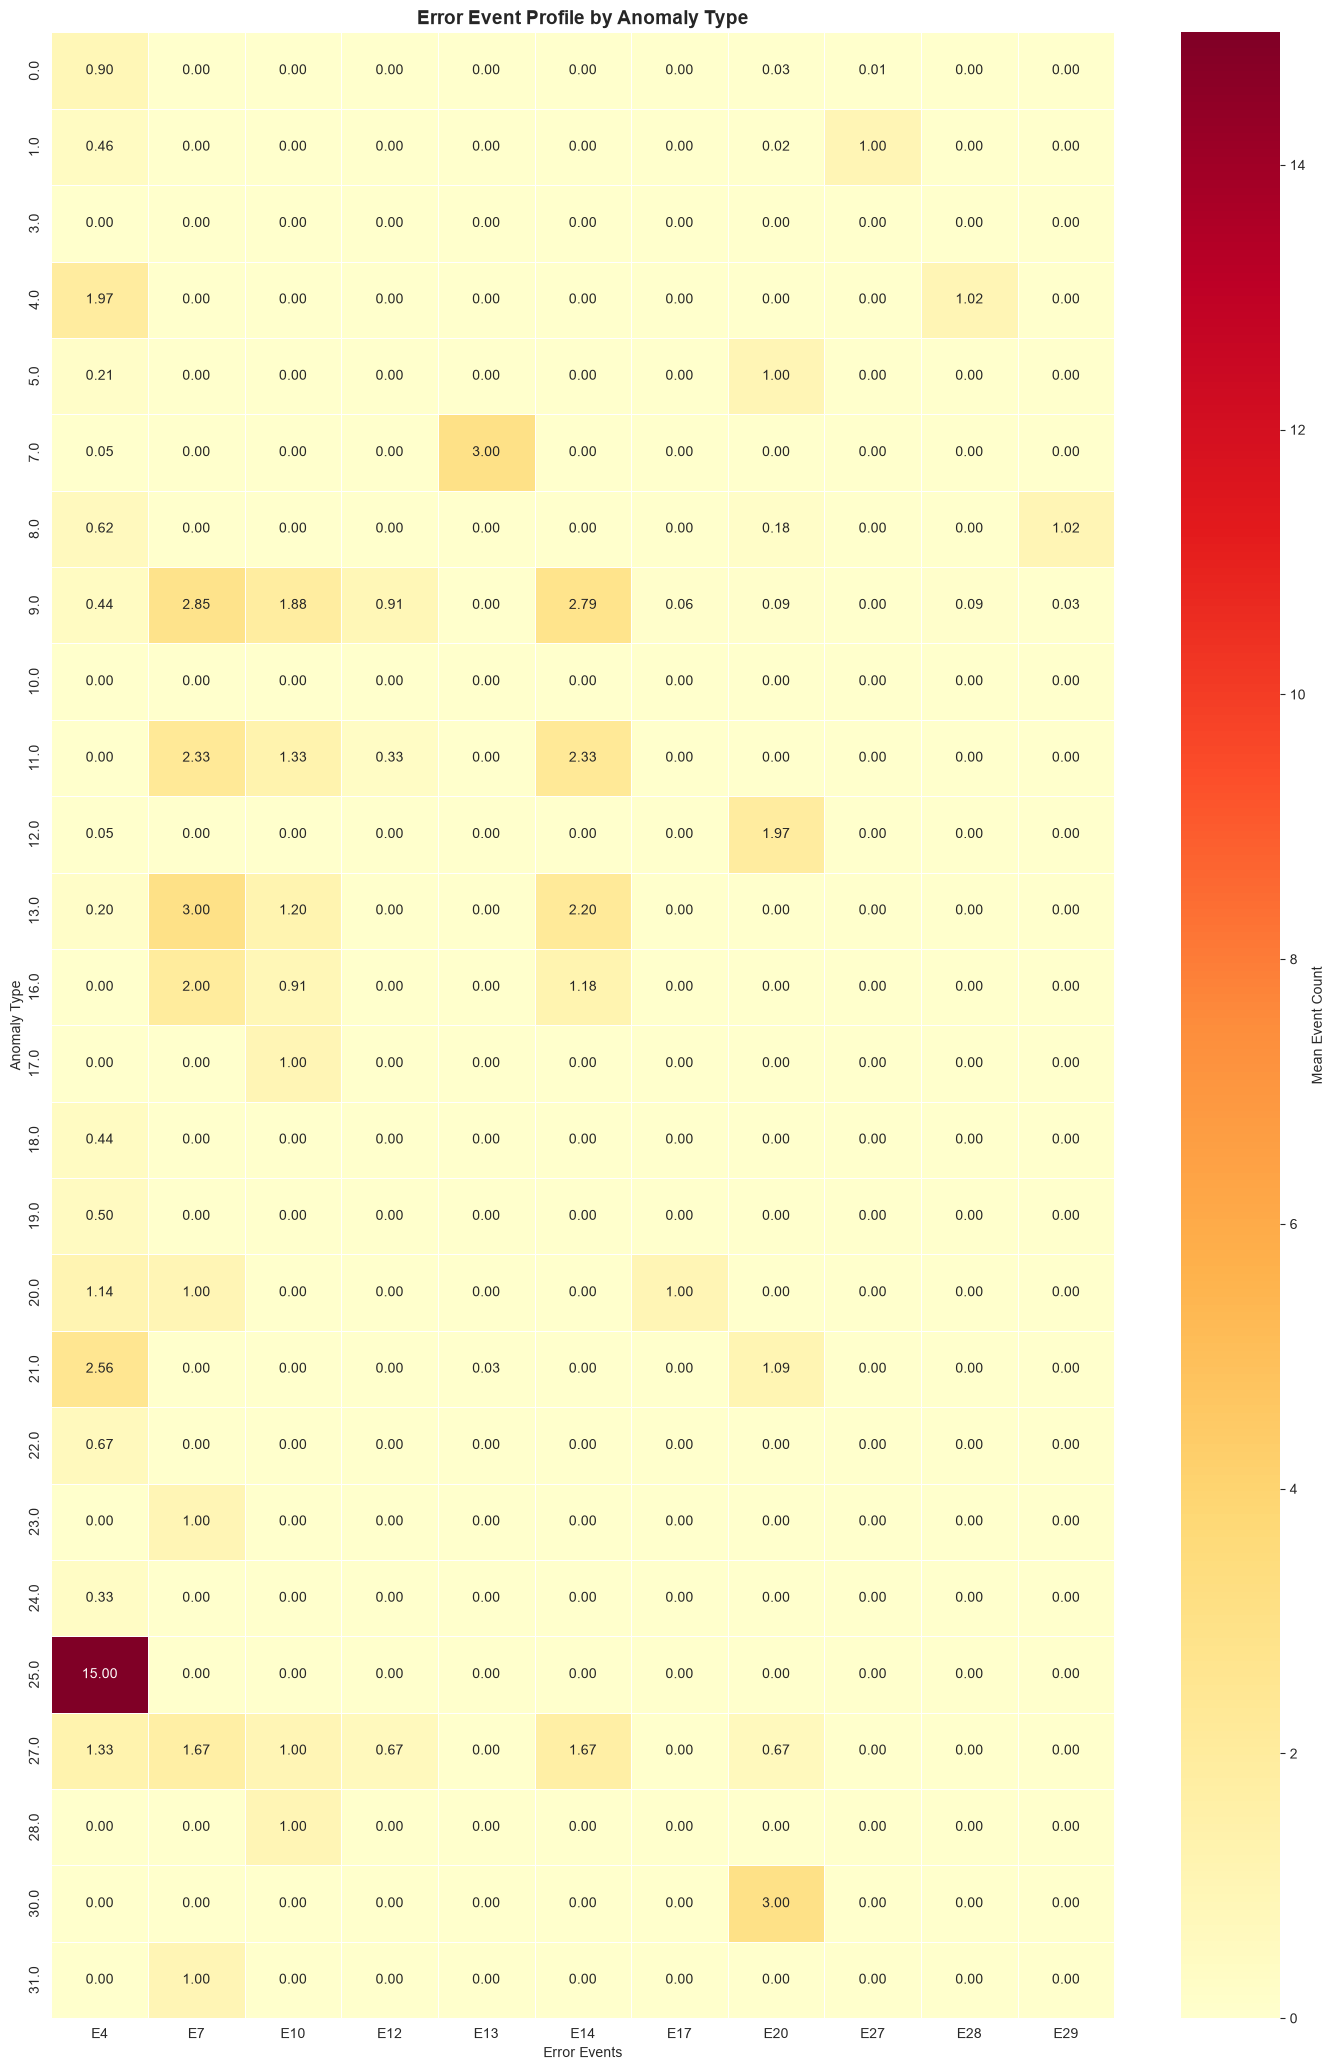


🔴 Dominant error event per anomaly type:
   Type   0: E4 (mean=0.90) — [*]Got exception while serving[*]to[*]
   Type   1: E27 (mean=1.00) — [*]BLOCK* NameSystem[*]addStoredBlock: Redundant addStoredBl
   Type   3: E4 (mean=0.00) — [*]Got exception while serving[*]to[*]
   Type   4: E4 (mean=1.97) — [*]Got exception while serving[*]to[*]
   Type   5: E20 (mean=1.00) — [*]Unexpected error trying to delete block[*]BlockInfo not f
   Type   7: E13 (mean=3.00) — [*]Receiving empty packet for block[*]
   Type   8: E29 (mean=1.02) — [*]PendingReplicationMonitor timed out block[*]
   Type   9: E7 (mean=2.85) — [*]writeBlock[*]received exception[*]
   Type  10: E4 (mean=0.00) — [*]Got exception while serving[*]to[*]
   Type  11: E7 (mean=2.33) — [*]writeBlock[*]received exception[*]
   Type  12: E20 (mean=1.97) — [*]Unexpected error trying to delete block[*]BlockInfo not f
   Type  13: E7 (mean=3.00) — [*]writeBlock[*]received exception[*]
   Type  16: E7 (mean=2.00) — [*]writeBlock[*]receive

In [38]:
anomaly_merged = merged[merged['Label_trace'] == 'Fail'].copy()

# Error-related events
error_events = ['E4', 'E7', 'E10', 'E12', 'E13', 'E14', 'E17', 'E20', 'E27', 'E28', 'E29']

# Compute mean error event count per anomaly type
type_profiles = anomaly_merged.groupby('Type_matrix')[error_events].mean()

# Heatmap
fig, ax = plt.subplots(figsize=(14, max(6, len(type_profiles) * 0.8)))
sns.heatmap(type_profiles, annot=True, fmt='.2f', cmap='YlOrRd', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean Event Count'})
ax.set_title('Error Event Profile by Anomaly Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Error Events')
ax.set_ylabel('Anomaly Type')
plt.tight_layout()
plt.savefig('../outputs/error_fingerprint_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the dominant error per type
print("\n🔴 Dominant error event per anomaly type:")
for atype in type_profiles.index:
    row = type_profiles.loc[atype]
    dominant = row.idxmax()
    dominant_val = row.max()
    template = templates_df[templates_df['EventId']==dominant]['EventTemplate'].values[0]
    print(f"   Type {int(atype):>3}: {dominant} (mean={dominant_val:.2f}) — {template[:60]}")

 ## Step 3: Build the Failure Mode Taxonomy

Now we cluster the anomaly types into **meaningful failure categories** based on which error events dominate. This is semi-manual work — we use the data to inform our categorization, but the category *names* and *descriptions* come from our domain knowledge of HDFS.

The categories we identified in NB02/NB03:
1. **Write Path Failure** — E7 (writeBlock exception), E12 (write to mirror exception)
2. **Empty Packet / Data Corruption** — E13 (empty packet)
3. **Serve Failure** — E4 (exception serving)
4. **Metadata Inconsistency** — E27 (redundant addStoredBlock), E28 (block doesn't belong to file)
5. **Replication/Transfer Failure** — E17 (failed to transfer), E29 (replication timeout)
6. **Block Lifecycle Error** — E20 (unexpected delete error), E14 (receiveBlock exception)


In [39]:
# Define failure mode mapping based on dominant error events
# This is informed by data but uses domain knowledge for naming

failure_modes = {
    "WRITE_PATH_FAILURE": {
        "description": "Block write operation failed during data pipeline replication",
        "key_events": ["E7", "E12"],
        "symptoms": "writeBlock exception followed by mirror write exception; block allocated but never fully received",
        "root_cause": "Destination DataNode disk failure, network interruption during write pipeline, or insufficient disk space",
        "remediation": {
            "action": "restart_datanode",
            "priority": "HIGH",
            "details": "Restart the affected DataNode and verify disk health"
        },
        "4gram_signatures": ["E22,E5,E5,E7", "E5,E5,E22,E7", "E5,E22,E5,E7"]
    },
    "EMPTY_PACKET_LOOP": {
        "description": "System stuck receiving empty packets in a loop, indicating data corruption",
        "key_events": ["E13"],
        "symptoms": "Cyclical pattern of receive → empty packet → terminate → receive; no useful data transferred",
        "root_cause": "Network packet corruption, source node memory error, or corrupted data in write pipeline",
        "remediation": {
            "action": "check_network_and_restart",
            "priority": "HIGH",
            "details": "Check network integrity between source and destination DataNodes, restart affected nodes"
        },
        "4gram_signatures": ["E9,E13,E11,E9", "E11,E9,E13,E11", "E13,E11,E9,E13"]
    },
    "SERVE_FAILURE": {
        "description": "Block serving to clients failed, triggering emergency re-replication",
        "key_events": ["E4", "E25"],
        "symptoms": "Block served successfully then hit exception; system requests replication of new copy",
        "root_cause": "DataNode going offline during read operations, node crash, or disk failure during serve",
        "remediation": {
            "action": "trigger_replication",
            "priority": "MEDIUM",
            "details": "Ensure block has sufficient replicas; if not, trigger re-replication to healthy nodes"
        },
        "4gram_signatures": ["E3,E3,E4,E25", "E3,E4,E3,E25", "E21,E3,E3,E4"]
    },
    "METADATA_INCONSISTENCY": {
        "description": "NameNode metadata became inconsistent with actual block state",
        "key_events": ["E27", "E28"],
        "symptoms": "Redundant addStoredBlock requests; blocks reported stored but don't belong to any file",
        "root_cause": "Network delays caused retransmission of block reports, leading to stale metadata in NameNode",
        "remediation": {
            "action": "run_fsck",
            "priority": "MEDIUM",
            "details": "Run HDFS fsck to verify and repair filesystem metadata consistency"
        },
        "4gram_signatures": ["E26,E26,E26,E27", "E26,E27,E23,E23", "E9,E26,E26,E27"]
    },
    "REPLICATION_FAILURE": {
        "description": "Block replication or transfer between DataNodes failed",
        "key_events": ["E17", "E29"],
        "symptoms": "Transfer failed events or replication monitor timeout; block under-replicated",
        "root_cause": "Target DataNode unreachable, network partition, or cluster overloaded preventing timely replication",
        "remediation": {
            "action": "increase_replication",
            "priority": "HIGH",
            "details": "Check cluster network connectivity; increase replication factor or add new DataNodes"
        },
        "4gram_signatures": []
    },
    "BLOCK_LIFECYCLE_ERROR": {
        "description": "Error during block receive or delete operations",
        "key_events": ["E14", "E20", "E10"],
        "symptoms": "Exception in receiveBlock, unexpected delete errors, or PacketResponder exceptions",
        "root_cause": "Block corruption, stale block references in volumeMap, or interrupted block operations",
        "remediation": {
            "action": "check_disk_and_cleanup",
            "priority": "MEDIUM",
            "details": "Verify disk health on affected DataNode; clean up orphaned blocks and stale references"
        },
        "4gram_signatures": []
    }
}
# Add the newly discovered failure modes
failure_modes["INCOMPLETE_PIPELINE"] = {
    "description": "Block write pipeline started but terminated silently without completion or error",
    "key_events": [],
    "detection_method": "sequence_length",
    "detection_rule": "Trace contains E5 and E22 but sequence length <= 3 and no completion events (E9, E11, E26, E2)",
    "symptoms": "Very short trace with only pipeline initialization events; no errors and no completion",
    "root_cause": "DataNode process killed (OOM), hardware failure, power loss, or catastrophic network partition before error could be logged",
    "remediation": {
        "action": "check_node_survival",
        "priority": "CRITICAL",
        "details": "Verify DataNode is alive; check OS logs for OOM kills; verify disk/network hardware; re-replicate affected blocks"
    },
    "4gram_signatures": []
}

failure_modes["SILENT_RECOVERY"] = {
    "description": "Block operations triggered emergency replication without logging an explicit error",
    "key_events": ["E25", "E18"],
    "detection_method": "event_presence",
    "detection_rule": "Trace contains E25 (ask to replicate) or E18 (transfer thread) without any error events",
    "symptoms": "Apparently successful operations followed by replication requests; no error events present",
    "root_cause": "Transient failure detected by HDFS's internal monitoring but not severe enough to generate error logs",
    "remediation": {
        "action": "monitor_cluster_health",
        "priority": "MEDIUM",
        "details": "Monitor cluster for recurring transient failures; check for intermittent network issues"
    },
    "4gram_signatures": []
}


# Print the taxonomy nicely
print(f"{'═'*70}")
print(f"  FAILURE MODE TAXONOMY ({len(failure_modes)} categories)")
print(f"{'═'*70}")

for mode_name, mode_info in failure_modes.items():
    print(f"\n  📌 {mode_name}")
    print(f"     Description: {mode_info['description']}")
    print(f"     Key Events:  {', '.join(mode_info['key_events'])}")
    print(f"     Root Cause:  {mode_info['root_cause'][:80]}...")
    print(f"     Action:      {mode_info['remediation']['action']} ({mode_info['remediation']['priority']})")


══════════════════════════════════════════════════════════════════════
  FAILURE MODE TAXONOMY (8 categories)
══════════════════════════════════════════════════════════════════════

  📌 WRITE_PATH_FAILURE
     Description: Block write operation failed during data pipeline replication
     Key Events:  E7, E12
     Root Cause:  Destination DataNode disk failure, network interruption during write pipeline, o...
     Action:      restart_datanode (HIGH)

  📌 EMPTY_PACKET_LOOP
     Description: System stuck receiving empty packets in a loop, indicating data corruption
     Key Events:  E13
     Root Cause:  Network packet corruption, source node memory error, or corrupted data in write ...
     Action:      check_network_and_restart (HIGH)

  📌 SERVE_FAILURE
     Description: Block serving to clients failed, triggering emergency re-replication
     Key Events:  E4, E25
     Root Cause:  DataNode going offline during read operations, node crash, or disk failure durin...
     Action:      tr

##  Step 4: Map Each Anomaly Type to a Failure Mode

Now we automatically classify each anomaly type into one of our failure modes by checking which category's key events are most prevalent in that type's error profile.


In [40]:
# Investigate the UNKNOWN types — what events DO they have?
unknown_types = [atype for atype, info in type_to_mode.items() 
                 if info['failure_mode'] == 'UNKNOWN_FAILURE']

if unknown_types:
    print(f"\n🔍 Investigating {len(unknown_types)} UNKNOWN failure types:")
    for atype in unknown_types:
        subset = anomaly_merged[anomaly_merged['Type_trace'] == atype]
        count = len(subset)
        
        # Get mean of ALL events (not just error events)
        all_means = subset[event_cols].mean().sort_values(ascending=False)
        top_events = all_means[all_means > 0].head(10)
        
        print(f"\n   Type {atype} ({count:,} traces):")
        print(f"   Top events present:")
        for evt, mean_val in top_events.items():
            template = templates_df[templates_df['EventId']==evt]['EventTemplate'].values[0][:50]
            print(f"      {evt}: mean={mean_val:.2f} — {template}")
        
        # Show a sample sequence
        sample_seq = anomaly_traces[anomaly_traces['Type'] == atype]['sequence'].iloc[0]
        print(f"   Sample sequence: {' → '.join(sample_seq[:15])}...")


# Save the Complete Taxonomy 

In [41]:
type_to_mode = {}

for atype in type_profiles.index:
    row = type_profiles.loc[atype]
    
    # Check for INCOMPLETE_PIPELINE first (special case: no error events at all)
    error_total = sum(row.get(evt, 0) for evt in error_events)
    
    # Get mean sequence length for this type
    type_traces = anomaly_traces[anomaly_traces['Type'] == atype]
    mean_seq_len = type_traces['seq_length'].mean()
    
    if error_total == 0 and mean_seq_len <= 5:
        # Very short trace with no errors = incomplete pipeline
        best_mode = "INCOMPLETE_PIPELINE"
        best_score = 0.0
    elif error_total == 0:
        # Longer trace but no errors = silent recovery
        best_mode = "SILENT_RECOVERY"
        best_score = 0.0
    else:
        # Normal matching
        best_mode = None
        best_score = 0
        for mode_name, mode_info in failure_modes.items():
            if mode_name in ["INCOMPLETE_PIPELINE", "SILENT_RECOVERY"]:
                continue  # Skip special modes in normal matching
            score = sum(row.get(evt, 0) for evt in mode_info['key_events'] if evt in row.index)
            if score > best_score:
                best_score = score
                best_mode = mode_name
        
        if best_mode is None:
            best_mode = "UNKNOWN_FAILURE"
    
    type_to_mode[int(atype)] = {
        "failure_mode": best_mode,
        "score": float(best_score),
        "count": int(anomaly_types[atype]),
        "mean_seq_length": float(mean_seq_len)
    }

# Print mapping
print(f"\n{'Type':>6} {'Count':>7} {'Avg Len':>8} {'Failure Mode':<30} {'Score':>6}")
print(f"{'─'*65}")
for atype, info in sorted(type_to_mode.items()):
    print(f"{atype:>6} {info['count']:>7,} {info['mean_seq_length']:>8.1f} {info['failure_mode']:<30} {info['score']:>6.2f}")

# Count traces per failure mode
mode_counts = {}
for atype, info in type_to_mode.items():
    mode = info['failure_mode']
    mode_counts[mode] = mode_counts.get(mode, 0) + info['count']

print(f"\n📊 Traces per failure mode:")
for mode, count in sorted(mode_counts.items(), key=lambda x: x[1], reverse=True):
    pct = count / len(anomaly_traces) * 100
    print(f"   {mode:<30} {count:>7,} ({pct:.1f}%)")



  Type   Count  Avg Len Failure Mode                    Score
─────────────────────────────────────────────────────────────────
     0   2,809     31.9 SERVE_FAILURE                    0.90
     1     953     20.8 METADATA_INCONSISTENCY           1.00
     3   2,950      2.0 INCOMPLETE_PIPELINE              0.00
     4   1,240     26.4 SERVE_FAILURE                    1.97
     5   4,167     21.7 BLOCK_LIFECYCLE_ERROR            1.00
     7     476     21.5 EMPTY_PACKET_LOOP                3.00
     8      45     30.8 REPLICATION_FAILURE              1.02
     9      34     40.2 BLOCK_LIFECYCLE_ERROR            4.76
    10       3     29.0 SILENT_RECOVERY                  0.00
    11       3     22.7 BLOCK_LIFECYCLE_ERROR            3.67
    12     130     22.8 BLOCK_LIFECYCLE_ERROR            1.97
    13      10     19.3 BLOCK_LIFECYCLE_ERROR            3.40
    16      22      8.5 BLOCK_LIFECYCLE_ERROR            2.09
    17       3     34.0 BLOCK_LIFECYCLE_ERROR            1.00
   

In [42]:
# Combine everything into the final knowledge base
knowledge_base = {
    "failure_modes": failure_modes,
    "type_to_mode_mapping": type_to_mode,
    "normal_baseline": {
        "median_latency": float(normal_traces['Latency'].median()),
        "mean_latency": float(normal_traces['Latency'].mean()),
        "typical_events": ["E5", "E22", "E9", "E11", "E26", "E2", "E3", "E21", "E23"],
    },
    "event_templates": {
        row['EventId']: row['EventTemplate'] 
        for _, row in templates_df.iterrows()
    },
    "anomaly_exclusive_4grams": seq_findings.get("anomaly_exclusive_4grams", []),
}

output_path = '../data/root_cause_taxonomy.json'
with open(output_path, 'w') as f:
    json.dump(knowledge_base, f, indent=2)

print(f"✅ Saved complete knowledge base to {output_path}")
print(f"   {len(knowledge_base['failure_modes'])} failure modes")
print(f"   {len(knowledge_base['type_to_mode_mapping'])} anomaly type mappings")
print(f"   {len(knowledge_base['event_templates'])} event templates")
print(f"   {len(knowledge_base['anomaly_exclusive_4grams'])} anomaly-exclusive 4-grams")


✅ Saved complete knowledge base to ../data/root_cause_taxonomy.json
   8 failure modes
   26 anomaly type mappings
   29 event templates
   30 anomaly-exclusive 4-grams
